In [1]:
#dataset = https://www.kaggle.com/datasets/isfaqueansari/lending-club

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv('Datasets/loan_data.csv')

In [8]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [9]:
df = pd.get_dummies(df, columns = ['purpose'], drop_first = True)

In [10]:
x = df.drop(columns = ['not.fully.paid'])
y = df['not.fully.paid']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

# **Decision Tree**

In [12]:
dtree = DecisionTreeClassifier()

In [13]:
dtree.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
predictions = dtree.predict(x_test)

In [15]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      2408
           1       0.21      0.22      0.21       466

    accuracy                           0.74      2874
   macro avg       0.53      0.53      0.53      2874
weighted avg       0.74      0.74      0.74      2874



<Axes: >

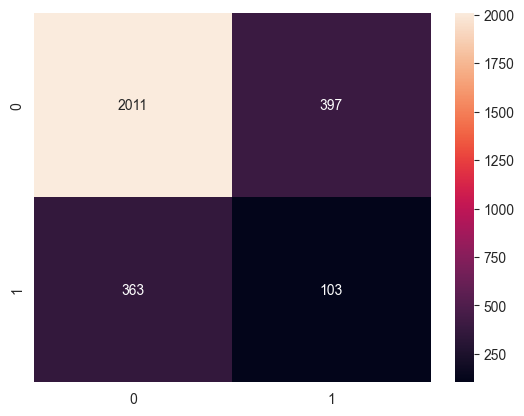

In [21]:
sns.heatmap(confusion_matrix(y_test, predictions), annot = True, fmt = 'd')

# **Random Forest**

In [22]:
rfc = RandomForestClassifier(n_estimators = 300)

In [23]:
rfc.fit(x_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
predictios2 = rfc.predict(x_test)

In [25]:
print(classification_report(y_test, predictios2))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2408
           1       0.40      0.02      0.03       466

    accuracy                           0.84      2874
   macro avg       0.62      0.51      0.47      2874
weighted avg       0.77      0.84      0.77      2874



<Axes: >

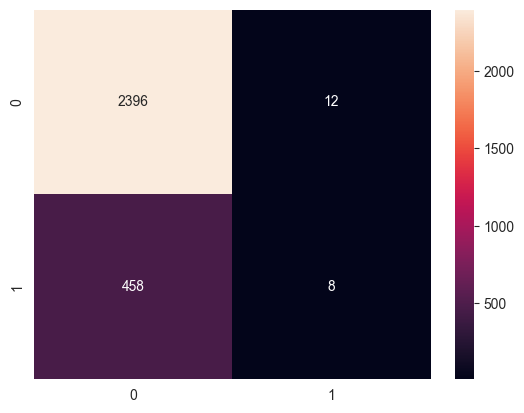

In [26]:
sns.heatmap(confusion_matrix(y_test, predictios2), annot = True, fmt = 'd')